In [ ]:
import pandas as pd

In [ ]:
from google.colab import files
files.upload()

Saving iris.csv to iris.csv


{'iris.csv': b'sepal_length,sepal_width,petal_length,petal_width,species\n5.1,3.5,1.4,0.2,setosa\n4.9,3.0,1.4,0.2,setosa\n4.7,3.2,1.3,0.2,setosa\n4.6,3.1,1.5,0.2,setosa\n5.0,3.6,1.4,0.2,setosa\n5.4,3.9,1.7,0.4,setosa\n4.6,3.4,1.4,0.3,setosa\n5.0,3.4,1.5,0.2,setosa\n4.4,2.9,1.4,0.2,setosa\n4.9,3.1,1.5,0.1,setosa\n5.4,3.7,1.5,0.2,setosa\n4.8,3.4,1.6,0.2,setosa\n4.8,3.0,1.4,0.1,setosa\n4.3,3.0,1.1,0.1,setosa\n5.8,4.0,1.2,0.2,setosa\n5.7,4.4,1.5,0.4,setosa\n5.4,3.9,1.3,0.4,setosa\n5.1,3.5,1.4,0.3,setosa\n5.7,3.8,1.7,0.3,setosa\n5.1,3.8,1.5,0.3,setosa\n5.4,3.4,1.7,0.2,setosa\n5.1,3.7,1.5,0.4,setosa\n4.6,3.6,1.0,0.2,setosa\n5.1,3.3,1.7,0.5,setosa\n4.8,3.4,1.9,0.2,setosa\n5.0,3.0,1.6,0.2,setosa\n5.0,3.4,1.6,0.4,setosa\n5.2,3.5,1.5,0.2,setosa\n5.2,3.4,1.4,0.2,setosa\n4.7,3.2,1.6,0.2,setosa\n4.8,3.1,1.6,0.2,setosa\n5.4,3.4,1.5,0.4,setosa\n5.2,4.1,1.5,0.1,setosa\n5.5,4.2,1.4,0.2,setosa\n4.9,3.1,1.5,0.1,setosa\n5.0,3.2,1.2,0.2,setosa\n5.5,3.5,1.3,0.2,setosa\n4.9,3.1,1.5,0.1,setosa\n4.4,3.0,1.3,0.

In [ ]:
df = pd.read_csv('iris.csv')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
print(df.shape)
print(df['species'].value_counts())
print(df.isnull().sum())

(150, 5)
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["species"])
y = df["species"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9333333333333333


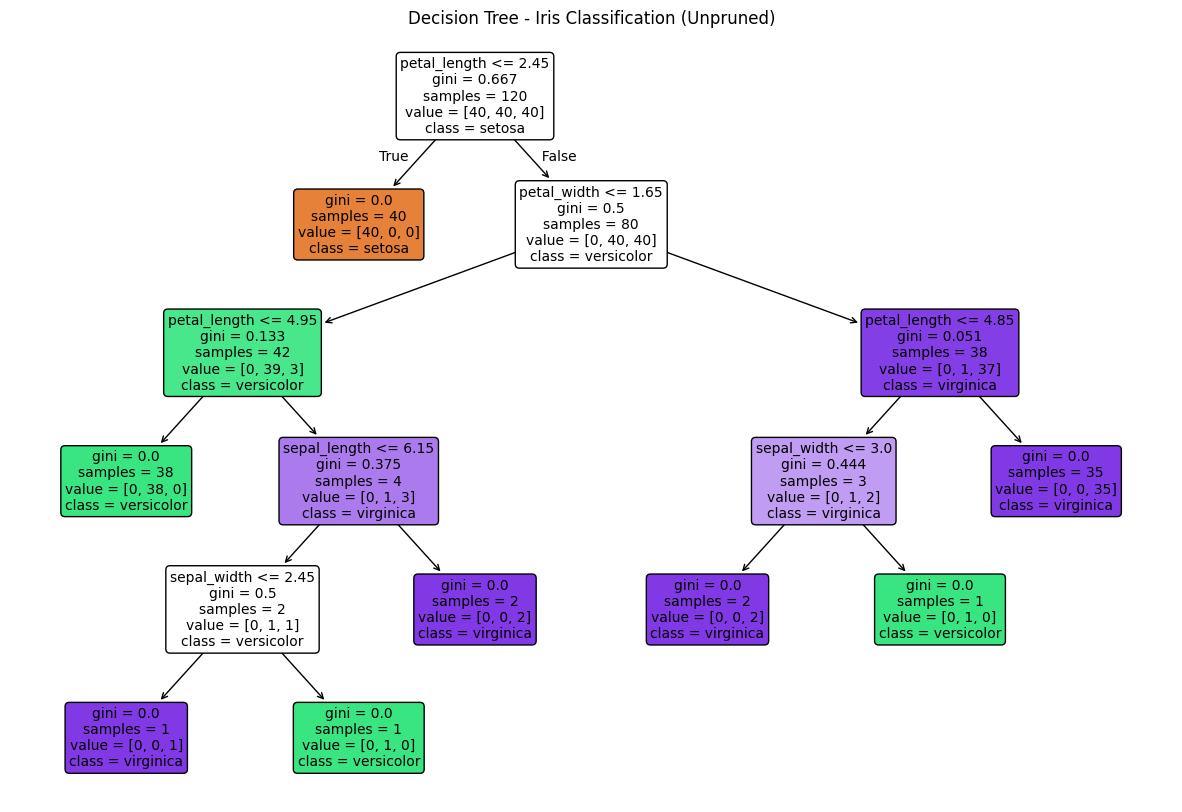

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plot_tree(model, feature_names=X.columns, class_names=model.classes_,
          filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree - Iris Classification (Unpruned)")
plt.show()

In [ ]:
model_pruned = DecisionTreeClassifier(max_depth=3, random_state=42)
model_pruned.fit(X_train, y_train)

y_pred_pruned = model_pruned.predict(X_test)
accuracy_pruned = accuracy_score(y_test, y_pred_pruned)
print("Accuracy (pruned, max_depth=3):", accuracy_pruned)

Accuracy (pruned, max_depth=3): 0.9666666666666667


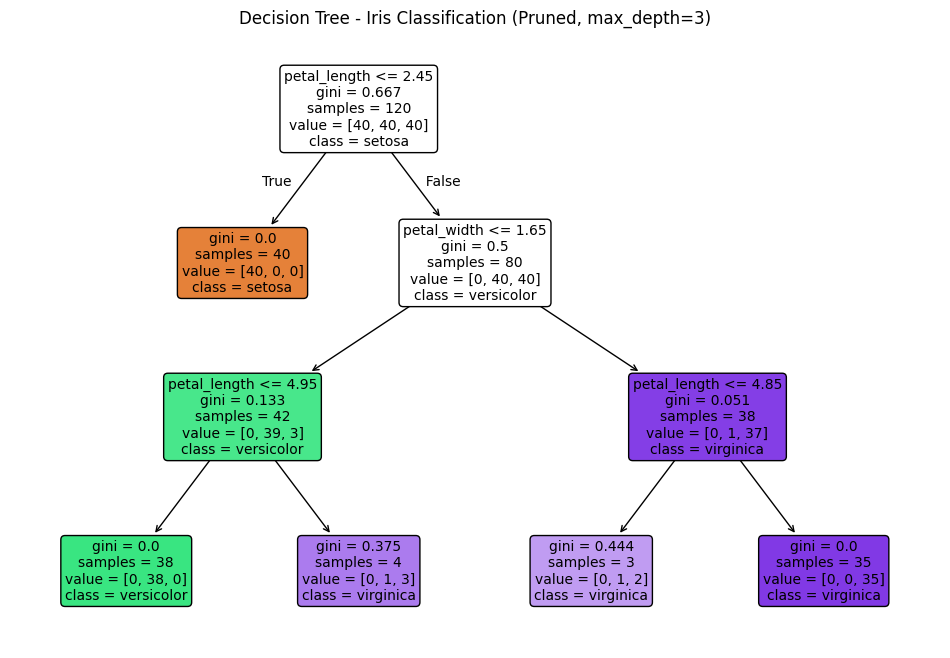

In [ ]:
plt.figure(figsize=(12, 8))
plot_tree(model_pruned, feature_names=X.columns, class_names=model.classes_,
          filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree - Iris Classification (Pruned, max_depth=3)")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_pruned))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [ ]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model_pruned.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance_df)

        Feature  Importance
2  petal_length    0.579077
3   petal_width    0.420923
1   sepal_width    0.000000
0  sepal_length    0.000000


## Conclusion

A Decision Tree classifier was trained on the Iris dataset to classify flowers into three species based on petal and sepal measurements.

The unpruned tree reached a depth of 6 levels and achieved 93.33% accuracy, but showed clear signs of overfitting — some branches split down to a single sample, learning noise rather than general patterns.

After pruning the tree to a maximum depth of 3, accuracy actually **improved to 96.67%**, with only 1 misclassification out of 30 test samples (a virginica sample predicted as versicolor). This demonstrates that a simpler, more generalized tree can outperform an overly complex one — a classic example of the overfitting vs. generalization trade-off.

Feature importance analysis revealed that the tree relies **entirely on petal measurements** (petal_length: 57.9%, petal_width: 42.1%), while sepal_length and sepal_width had zero importance — meaning petal size alone is sufficient to distinguish between the three species.

**Key takeaway:** Unlike KNN, Decision Trees don't require feature scaling since they split data based on threshold comparisons rather than distance calculations. Pruning (limiting tree depth) proved essential for preventing overfitting and improving generalization to unseen data.